In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.stochastic_sir import generate_dataset
from src.ml_model import train_model, evaluate

In [16]:
generate_dataset()

data = np.load("../results/stochastic_dataset.npz")

t = data["t"]
S = data["S"]
I = data["I"]
R = data["R"]

print("Dataset shape")
print("S:", S.shape)
print("I:", I.shape)
print("R:", R.shape)

Dataset saved: results/stochastic_dataset.npz
Dataset shape
S: (16, 160)
I: (16, 160)
R: (16, 160)


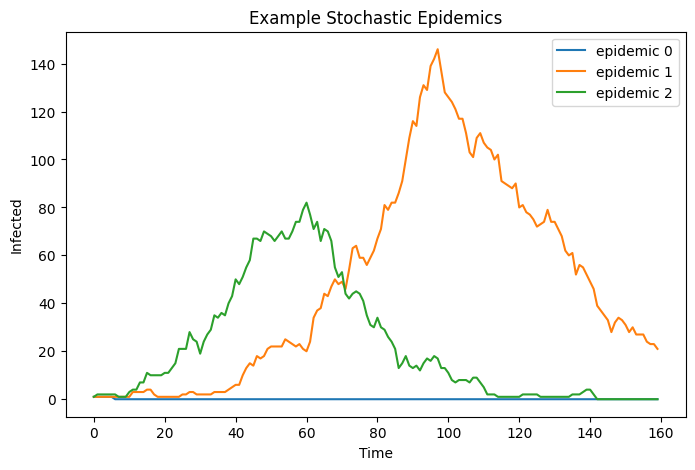

In [17]:
plt.figure(figsize=(8,5))

for i in range(3):
    plt.plot(t, I[i], label=f"epidemic {i}")

plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("Example Stochastic Epidemics")
plt.legend()
plt.show()

In [19]:
model, t_tensor, y_tensor = train_model()

Epoch 0 | Loss 0.211063
Epoch 500 | Loss 0.093724
Epoch 1000 | Loss 0.093697
Epoch 1500 | Loss 0.093713
Epoch 2000 | Loss 0.093692
Epoch 2500 | Loss 0.093691


MSE: 0.09369105100631714
R2: 0.2695257365703583
Error plot saved


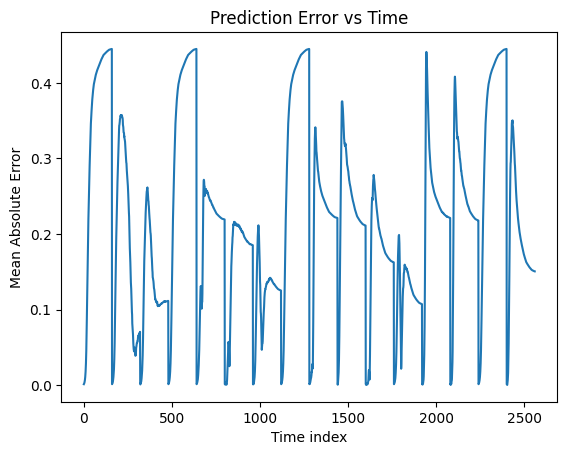

In [20]:
evaluate(model, t_tensor, y_tensor)

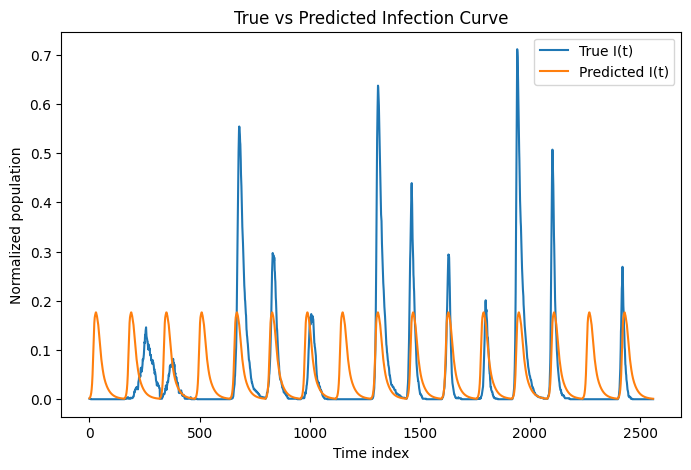

In [21]:
with torch.no_grad():
    pred = model(t_tensor).numpy()

y_true = y_tensor.numpy()

plt.figure(figsize=(8,5))

plt.plot(y_true[:,1], label="True I(t)")
plt.plot(pred[:,1], label="Predicted I(t)")

plt.title("True vs Predicted Infection Curve")
plt.xlabel("Time index")
plt.ylabel("Normalized population")
plt.legend()

plt.show()

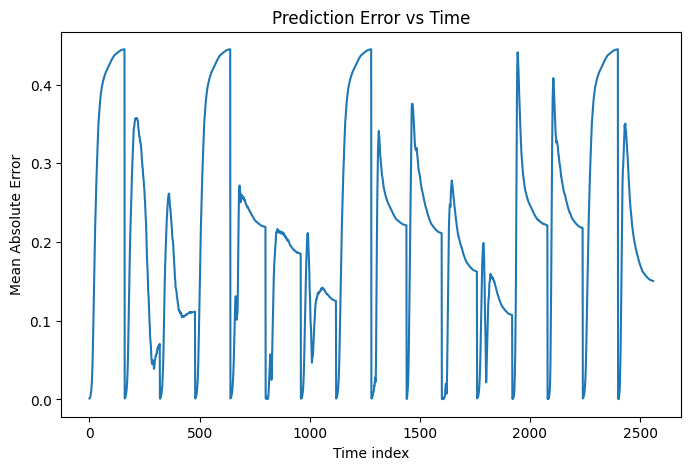

In [22]:
error = np.abs(y_true - pred).mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(error)

plt.title("Prediction Error vs Time")
plt.xlabel("Time index")
plt.ylabel("Mean Absolute Error")

plt.show()

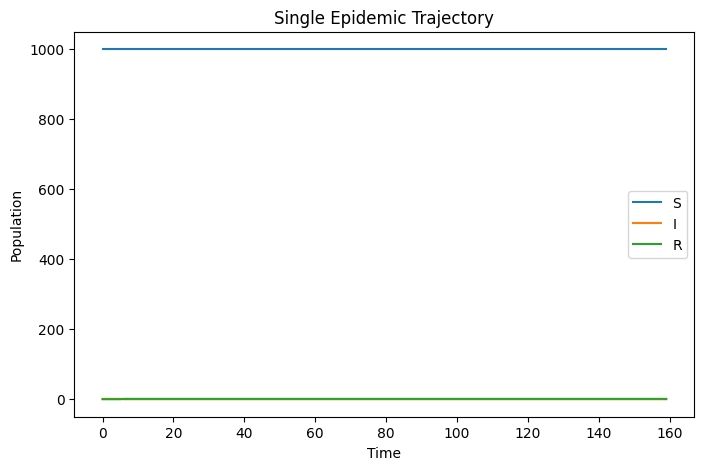

In [23]:
idx = 0

plt.figure(figsize=(8,5))

plt.plot(S[idx], label="S")
plt.plot(I[idx], label="I")
plt.plot(R[idx], label="R")

plt.title("Single Epidemic Trajectory")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()

plt.show()